# Train Influence Predictor (LOW / MEDIUM / HIGH)

**Luồng:** import → helper đánh giá → cấu hình → load dữ liệu → định nghĩa mô hình → chọn trên val → fit train+val → đánh giá test → lưu file.

| Phần | Nội dung |
|------|----------|
| 1–3 | Thư viện, `EvalResult` / `_evaluate`, `print_full_evaluation` |
| 4–5 | Đường dẫn, đọc CSV + label encoder |
| 6–9 | Ứng viên, kiểm tra model cũ, huấn luyện & chọn mô hình, đánh giá val |
| 10–13 | Fit train+val, test, lưu CSV / joblib / metadata |


## 1. Import thư viện


In [14]:
from __future__ import annotations

import json
from dataclasses import dataclass
from datetime import datetime, timezone
from pathlib import Path
from typing import Any

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import ExtraTreesClassifier, HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


## 2. `EvalResult`, `_evaluate`, `_rank_key`


In [15]:
@dataclass(frozen=True)
class EvalResult:
    macro_f1: float
    weighted_f1: float
    accuracy: float
    mae_class_distance: float

    def to_dict(self) -> dict[str, Any]:
        return {
            "macro_f1": self.macro_f1,
            "weighted_f1": self.weighted_f1,
            "accuracy": self.accuracy,
            "mae_class_distance": self.mae_class_distance,
        }


def _evaluate(y_true: np.ndarray, y_pred: np.ndarray) -> EvalResult:
    y_true = y_true.astype(int)
    y_pred = y_pred.astype(int)
    macro_f1 = float(f1_score(y_true, y_pred, average="macro", zero_division=0))
    weighted_f1 = float(f1_score(y_true, y_pred, average="weighted", zero_division=0))
    accuracy = float(accuracy_score(y_true, y_pred))
    mae = float(np.mean(np.abs(y_pred - y_true)))
    return EvalResult(
        macro_f1=macro_f1,
        weighted_f1=weighted_f1,
        accuracy=accuracy,
        mae_class_distance=mae,
    )


def _rank_key(res: EvalResult) -> tuple[float, float]:
    return (res.macro_f1, -res.mae_class_distance)


## 3. Đánh giá đầy đủ (Accuracy, Precision, Recall, F1, report, CM)


In [16]:
def print_full_evaluation(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    label_order: list[int],
    int_to_label: dict[str, str],
    title: str = "Evaluation",
) -> np.ndarray:
    labels = np.array(sorted(label_order))
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)
    names = [int_to_label[str(i)] for i in labels]

    acc = accuracy_score(y_true, y_pred)
    prec_macro = precision_score(y_true, y_pred, average="macro", zero_division=0)
    prec_weighted = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    rec_macro = recall_score(y_true, y_pred, average="macro", zero_division=0)
    rec_weighted = recall_score(y_true, y_pred, average="weighted", zero_division=0)
    f1_macro = f1_score(y_true, y_pred, average="macro", zero_division=0)
    f1_weighted = f1_score(y_true, y_pred, average="weighted", zero_division=0)

    sep = "=" * 60
    print(f"\n{sep}")
    print(f"  {title}")
    print(sep)
    print(f"Accuracy:           {acc:.4f}")
    print(f"Precision (macro):  {prec_macro:.4f}   (weighted): {prec_weighted:.4f}")
    print(f"Recall (macro):     {rec_macro:.4f}   (weighted): {rec_weighted:.4f}")
    print(f"F1 (macro):         {f1_macro:.4f}   (weighted): {f1_weighted:.4f}")
    print("\nClassification report (per class):")
    print(
        classification_report(
            y_true, y_pred, labels=labels, target_names=names, digits=4, zero_division=0
        )
    )

    cm = confusion_matrix(y_true, y_pred, labels=labels)
    print("Confusion matrix (rows=true, cols=pred):")
    print(pd.DataFrame(cm, index=[f"true_{n}" for n in names], columns=[f"pred_{n}" for n in names]))

    fig, ax = plt.subplots(figsize=(6, 5))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=names)
    disp.plot(ax=ax, cmap="Blues", colorbar=True)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()
    return cm


## 4. Cấu hình đường dẫn


In [17]:
from pathlib import Path

BASE_DIR = Path(".").resolve()
if not (BASE_DIR / "feature_engineering_output").exists() and (
    BASE_DIR.parent / "feature_engineering_output"
).exists():
    BASE_DIR = BASE_DIR.parent

DATA_DIR = BASE_DIR / "feature_engineering_output"
MODEL_OUT_DIR = BASE_DIR / "model" / "influence_predictor"
FORCE_RETRAIN = True

MODEL_OUT_DIR.mkdir(parents=True, exist_ok=True)
print("DATA_DIR:", DATA_DIR)
print("MODEL_OUT_DIR:", MODEL_OUT_DIR)


DATA_DIR: D:\KLTN4\extraction-system\feature_engineering_output
MODEL_OUT_DIR: D:\KLTN4\extraction-system\model\influence_predictor


## 5. Đọc `label_encoder` và các tập CSV


In [18]:
label_encoder_path = DATA_DIR / "label_encoder.json"
label_encoder = json.loads(label_encoder_path.read_text(encoding="utf-8"))
label_to_int: dict[str, int] = {k: int(v) for k, v in label_encoder["label_to_int"].items()}
int_to_label: dict[str, str] = label_encoder["int_to_label"]
label_order = sorted(label_to_int.values())

X_train = pd.read_csv(DATA_DIR / "X_train.csv")
y_train_df = pd.read_csv(DATA_DIR / "y_train.csv")
X_val = pd.read_csv(DATA_DIR / "X_val.csv")
y_val_df = pd.read_csv(DATA_DIR / "y_val.csv")
X_test = pd.read_csv(DATA_DIR / "X_test.csv")
y_test_df = pd.read_csv(DATA_DIR / "y_test.csv")

feature_names = list(X_train.columns)
for name, x in [("X_val", X_val), ("X_test", X_test)]:
    if list(x.columns) != feature_names:
        raise ValueError(f"{name} columns differ from X_train.")

y_train = y_train_df["label_int"].astype(int).to_numpy()
y_val = y_val_df["label_int"].astype(int).to_numpy()
y_test = y_test_df["label_int"].astype(int).to_numpy()
print("Shapes:", X_train.shape, X_val.shape, X_test.shape)


Shapes: (5100, 40) (1094, 40) (1094, 40)


## 6. Danh sách mô hình ứng viên


In [19]:
candidates: list[tuple[str, Any]] = [
    (
        "logreg_standard_scaler",
        Pipeline(
            steps=[
                ("scaler", StandardScaler(with_mean=True, with_std=True)),
                (
                    "clf",
                    LogisticRegression(
                        max_iter=3000,
                        solver="lbfgs",
                        class_weight="balanced",
                        n_jobs=None,
                        random_state=42,
                    ),
                ),
            ]
        ),
    ),
    (
        "rf_balanced_subsample",
        RandomForestClassifier(
            n_estimators=600,
            random_state=42,
            n_jobs=-1,
            class_weight="balanced_subsample",
            min_samples_leaf=1,
        ),
    ),
    (
        "extratrees_balanced",
        ExtraTreesClassifier(
            n_estimators=900,
            random_state=42,
            n_jobs=-1,
            class_weight="balanced",
            min_samples_leaf=1,
        ),
    ),
    (
        "histgb",
        HistGradientBoostingClassifier(
            max_depth=6,
            learning_rate=0.05,
            max_iter=500,
            random_state=42,
        ),
    ),
]


## 7. Đường dẫn file output & kiểm tra model đã tồn tại


In [20]:
model_path = MODEL_OUT_DIR / "influence_predictor.joblib"
meta_path = MODEL_OUT_DIR / "metadata.json"
if model_path.exists() and meta_path.exists() and not FORCE_RETRAIN:
    raise SystemExit(f"Model đã tồn tại tại {MODEL_OUT_DIR}. Đặt FORCE_RETRAIN = True để huấn luyện lại.")


## 8. Huấn luyện từng ứng viên trên `X_train`, đo trên validation


In [21]:
best_name = None
best_model = None
best_val_res = None

for name, model in candidates:
    model.fit(X_train, y_train)
    y_val_pred = model.predict(X_val)
    res = _evaluate(y_val, y_val_pred)
    print(
        f"[VAL] {name}: macro_f1={res.macro_f1:.4f}, weighted_f1={res.weighted_f1:.4f}, "
        f"acc={res.accuracy:.4f}, mae={res.mae_class_distance:.4f}"
    )
    if best_val_res is None or _rank_key(res) > _rank_key(best_val_res):
        best_name = name
        best_model = model
        best_val_res = res


[VAL] logreg_standard_scaler: macro_f1=0.8918, weighted_f1=0.8918, acc=0.8958, mae=0.1042
[VAL] rf_balanced_subsample: macro_f1=0.8881, weighted_f1=0.8881, acc=0.8903, mae=0.1097
[VAL] extratrees_balanced: macro_f1=0.8800, weighted_f1=0.8800, acc=0.8821, mae=0.1179
[VAL] histgb: macro_f1=0.8925, weighted_f1=0.8925, acc=0.8949, mae=0.1051


## 9. Xác nhận mô hình được chọn & đánh giá chi tiết trên validation



>>> Chọn mô hình: histgb

  Validation — histgb
Accuracy:           0.8949
Precision (macro):  0.9006   (weighted): 0.9007
Recall (macro):     0.8949   (weighted): 0.8949
F1 (macro):         0.8925   (weighted): 0.8925

Classification report (per class):
              precision    recall  f1-score   support

         LOW     0.8188    0.9560    0.8821       364
      MEDIUM     0.9281    0.7425    0.8250       365
        HIGH     0.9549    0.9863    0.9704       365

    accuracy                         0.8949      1094
   macro avg     0.9006    0.8949    0.8925      1094
weighted avg     0.9007    0.8949    0.8925      1094

Confusion matrix (rows=true, cols=pred):
             pred_LOW  pred_MEDIUM  pred_HIGH
true_LOW          348           16          0
true_MEDIUM        77          271         17
true_HIGH           0            5        360


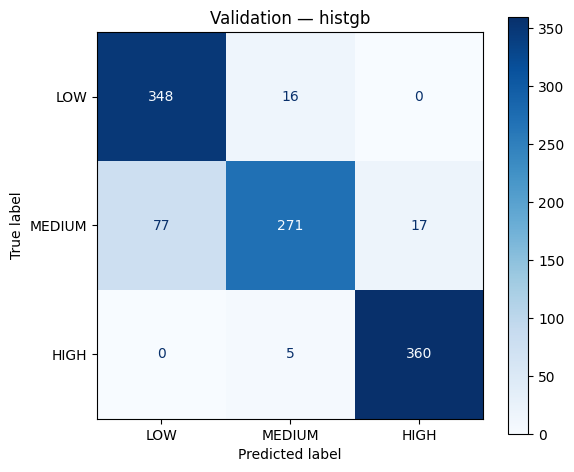

array([[348,  16,   0],
       [ 77, 271,  17],
       [  0,   5, 360]])

In [22]:
assert best_name is not None and best_model is not None and best_val_res is not None
print(f"\n>>> Chọn mô hình: {best_name}")
y_val_pred_best = best_model.predict(X_val)
print_full_evaluation(
    y_val, y_val_pred_best, label_order, int_to_label, title=f"Validation — {best_name}"
)


## 10. Huấn luyện lại trên train + validation


In [23]:
X_train_all = pd.concat([X_train, X_val], axis=0, ignore_index=True)
y_train_all = np.concatenate([y_train, y_val], axis=0)
best_model.fit(X_train_all, y_train_all)


,"loss loss: {'log_loss'}, default='log_loss'The loss function to use in the boosting process.For binary classification problems, 'log_loss' is also known as logistic loss,binomial deviance or binary crossentropy. Internally, the model fits one treeper boosting iteration and uses the logistic sigmoid function (expit) asinverse link function to compute the predicted positive class probability.For multiclass classification problems, 'log_loss' is also known as multinomialdeviance or categorical crossentropy. Internally, the model fits one tree perboosting iteration and per class and uses the softmax function as inverse linkfunction to compute the predicted probabilities of the classes.",'log_loss'
,"learning_rate learning_rate: float, default=0.1The learning rate, also known as *shrinkage*. This is used as amultiplicative factor for the leaves values. Use ``1`` for noshrinkage.",0.05
,"max_iter max_iter: int, default=100The maximum number of iterations of the boosting process, i.e. themaximum number of trees for binary classification. For multiclassclassification, `n_classes` trees per iteration are built.",500
,"max_leaf_nodes max_leaf_nodes: int or None, default=31The maximum number of leaves for each tree. Must be strictly greaterthan 1. If None, there is no maximum limit.",31
,"max_depth max_depth: int or None, default=NoneThe maximum depth of each tree. The depth of a tree is the number ofedges to go from the root to the deepest leaf.Depth isn't constrained by default.",6
,"min_samples_leaf min_samples_leaf: int, default=20The minimum number of samples per leaf. For small datasets with lessthan a few hundred samples, it is recommended to lower this valuesince only very shallow trees would be built.",20
,"l2_regularization l2_regularization: float, default=0The L2 regularization parameter penalizing leaves with small hessians.Use ``0`` for no regularization (default).",0.0
,"max_features max_features: float, default=1.0Proportion of randomly chosen features in each and every node split.This is a form of regularization, smaller values make the trees weakerlearners and might prevent overfitting.If interaction constraints from `interaction_cst` are present, only allowedfeatures are taken into account for the subsampling... versionadded:: 1.4",1.0
,"max_bins max_bins: int, default=255The maximum number of bins to use for non-missing values. Beforetraining, each feature of the input array `X` is binned intointeger-valued bins, which allows for a much faster training stage.Features with a small number of unique values may use less than``max_bins`` bins. In addition to the ``max_bins`` bins, one more binis always reserved for missing values. Must be no larger than 255.",255
,"categorical_features categorical_features: array-like of {bool, int, str} of shape (n_features) or shape (n_categorical_features,), default='from_dtype'Indicates the categorical features.- None : no feature will be considered categorical.- boolean array-like : boolean mask indicating categorical features.- integer array-like : integer indices indicating categorical features.- str array-like: names of categorical features (assuming the training data has feature names).- `""from_dtype""`: dataframe columns with dtype ""category"" are considered to be categorical features. The input must be an object exposing a ``__dataframe__`` method such as pandas or polars DataFrames to use this feature.For each categorical feature, there must be at most `max_bins` uniquecategories. Negative values for categorical features encoded as numericdtypes are treated as missing values. All categorical values areconverted to floating point numbers. This means that categorical valuesof 1.0 and 1 are treated as the same category.Read more in the :ref:`User Guide `... versionadded:: 0.24.. versionchanged:: 1.2 Added support for feature names... versionchanged:: 1.4 Added `""from_dtype""` option... versionchanged:: 1.6 The default value changed from `None` to `""from_dtype""`.",'from_dtyp

## 11. Dự đoán & đánh giá trên test



  Test — histgb
Accuracy:           0.8885
Precision (macro):  0.8957   (weighted): 0.8957
Recall (macro):     0.8883   (weighted): 0.8885
F1 (macro):         0.8859   (weighted): 0.8860

Classification report (per class):
              precision    recall  f1-score   support

         LOW     0.7986    0.9452    0.8657       365
      MEDIUM     0.9231    0.7253    0.8123       364
        HIGH     0.9654    0.9945    0.9798       365

    accuracy                         0.8885      1094
   macro avg     0.8957    0.8883    0.8859      1094
weighted avg     0.8957    0.8885    0.8860      1094

Confusion matrix (rows=true, cols=pred):
             pred_LOW  pred_MEDIUM  pred_HIGH
true_LOW          345           20          0
true_MEDIUM        87          264         13
true_HIGH           0            2        363


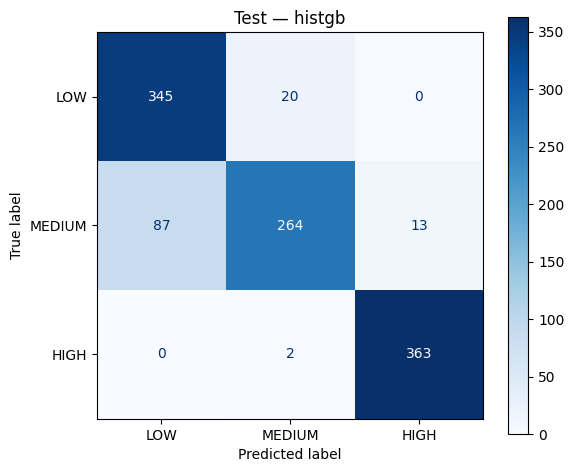

array([[345,  20,   0],
       [ 87, 264,  13],
       [  0,   2, 363]])

In [24]:
y_test_pred = best_model.predict(X_test)
test_res = _evaluate(y_test, y_test_pred)
print_full_evaluation(
    y_test, y_test_pred, label_order, int_to_label, title=f"Test — {best_name}"
)


## 12. Lưu `test_predictions.csv`


In [25]:
proba_path = MODEL_OUT_DIR / "test_predictions.csv"
pred_df = pd.DataFrame(
    {
        "y_true_int": y_test.astype(int),
        "y_true_label": [int_to_label[str(i)] for i in y_test.astype(int)],
        "y_pred_int": y_test_pred.astype(int),
        "y_pred_label": [int_to_label[str(i)] for i in y_test_pred.astype(int)],
    }
)
if hasattr(best_model, "predict_proba"):
    try:
        proba = best_model.predict_proba(X_test)
        pred_df["pred_proba_max"] = np.max(proba, axis=1)
    except Exception:
        pass
pred_df.to_csv(proba_path, index=False, encoding="utf-8")
print("Đã ghi:", proba_path)


Đã ghi: D:\KLTN4\extraction-system\model\influence_predictor\test_predictions.csv


## 13. Lưu model (`joblib`) và `metadata.json`


In [26]:
joblib.dump(best_model, model_path)

# val_cm: dự đoán val từ mô hình đã chọn (chỉ fit trên X_train), khớp train_influence_predictor.py
val_cm = confusion_matrix(y_val, y_val_pred_best, labels=label_order)

timestamp = datetime.now(timezone.utc).isoformat()
metadata = {
    "timestamp_utc": timestamp,
    "data_dir": str(DATA_DIR),
    "feature_names": feature_names,
    "label_encoder": label_encoder,
    "selected_model": best_name,
    "val_metrics": best_val_res.to_dict(),
    "val_confusion_matrix": val_cm.tolist(),
    "test_metrics": test_res.to_dict(),
    "test_confusion_matrix": confusion_matrix(y_test, y_test_pred, labels=label_order).tolist(),
    "test_extended_metrics": {
        "precision_macro": float(
            precision_score(y_test, y_test_pred, average="macro", zero_division=0)
        ),
        "precision_weighted": float(
            precision_score(y_test, y_test_pred, average="weighted", zero_division=0)
        ),
        "recall_macro": float(recall_score(y_test, y_test_pred, average="macro", zero_division=0)),
        "recall_weighted": float(
            recall_score(y_test, y_test_pred, average="weighted", zero_division=0)
        ),
    },
    "splits": {
        "X_train": "X_train.csv",
        "y_train": "y_train.csv",
        "X_val": "X_val.csv",
        "y_val": "y_val.csv",
        "X_test": "X_test.csv",
        "y_test": "y_test.csv",
    },
}
meta_path.write_text(json.dumps(metadata, ensure_ascii=False, indent=2), encoding="utf-8")

print(f"Saved model: {model_path}")
print(f"Saved metadata: {meta_path}")


Saved model: D:\KLTN4\extraction-system\model\influence_predictor\influence_predictor.joblib
Saved metadata: D:\KLTN4\extraction-system\model\influence_predictor\metadata.json
